In [1]:
import os
import sys
import cv2
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../.."))
sys.path.append(PROJECT_ROOT)
from app.modelsAI.insightFace.model import cosine_sim, app
import matplotlib.pyplot as plt
from app.utils.cropImage import cropImage


/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/macos/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/macos/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/macos/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/macos/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /Users/macos/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
se

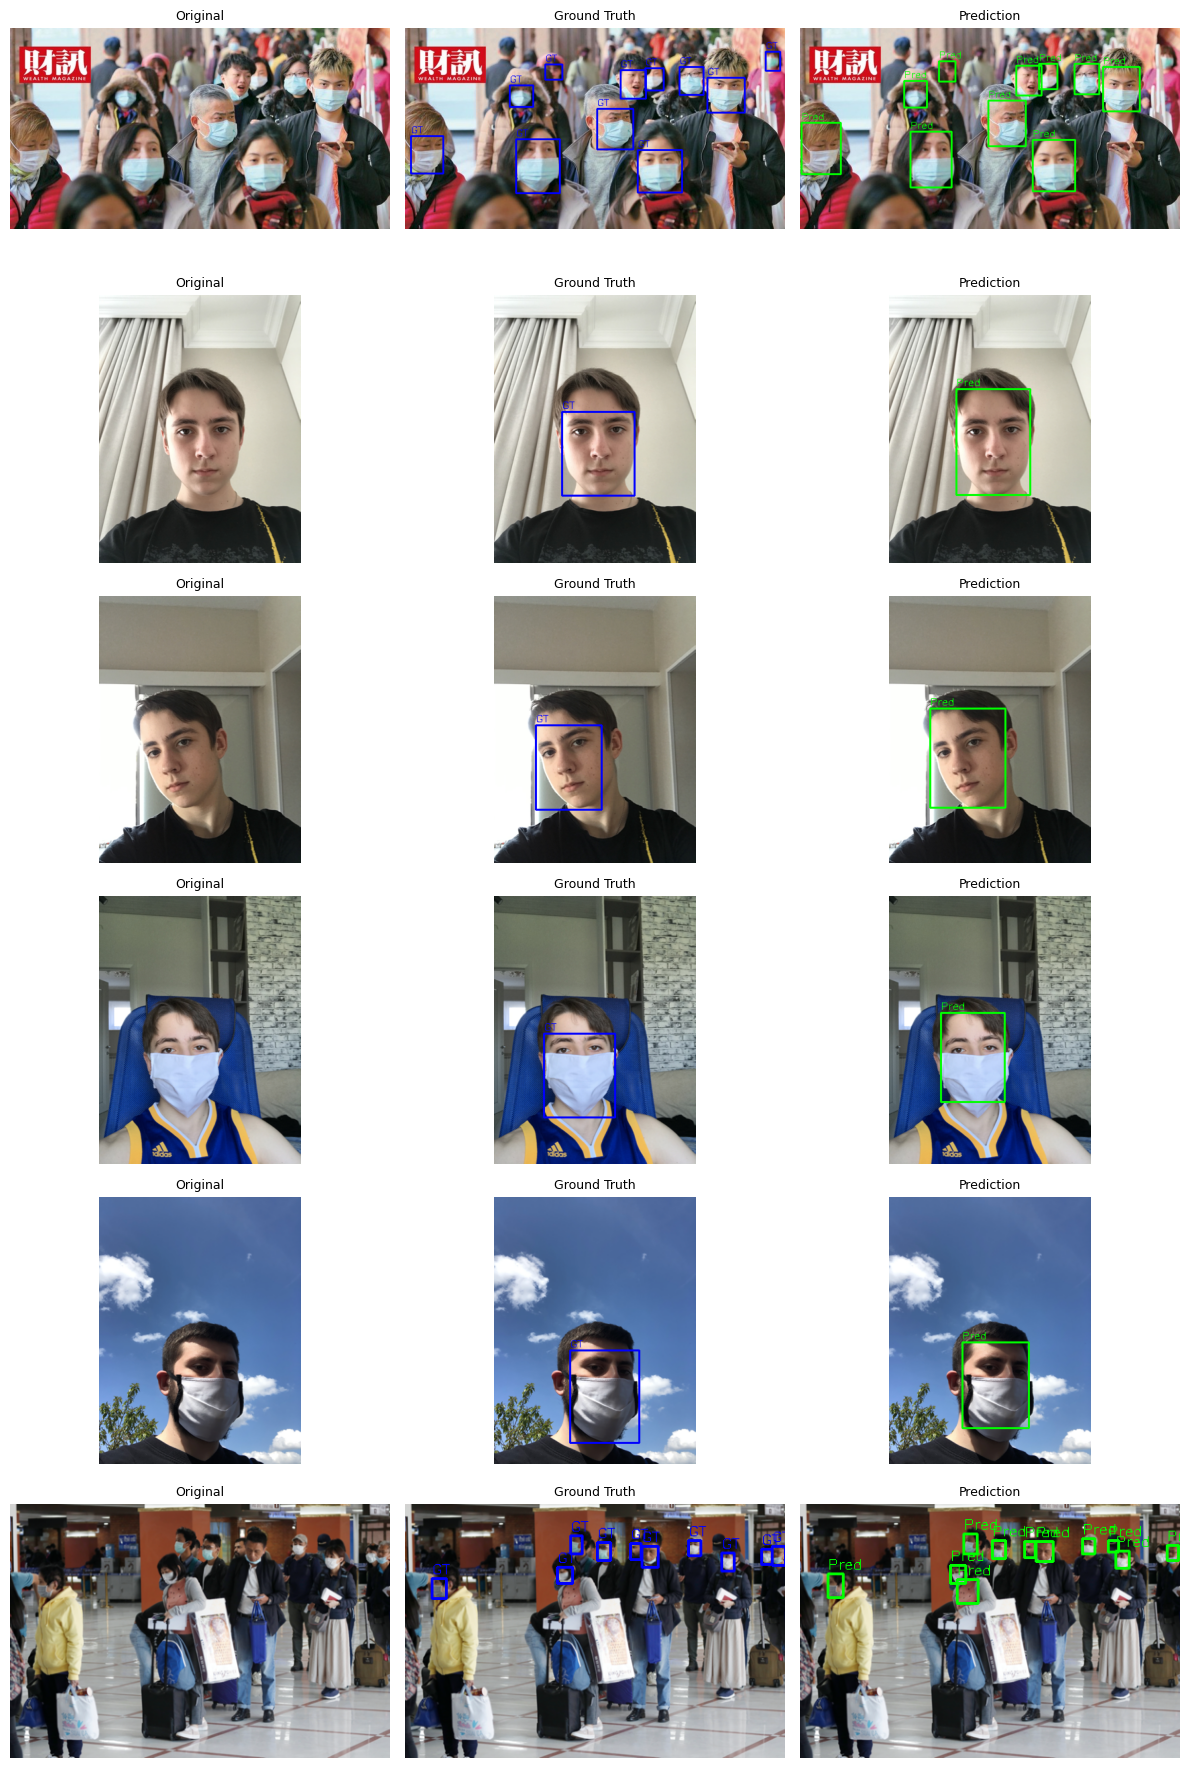

In [10]:
import os
import cv2
import matplotlib.pyplot as plt
import xml.etree.ElementTree as ET

def parse_voc_xml(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()
    boxes = []
    for obj in root.findall("object"):
        bnd = obj.find("bndbox")
        xmin = int(bnd.find("xmin").text)
        ymin = int(bnd.find("ymin").text)
        xmax = int(bnd.find("xmax").text)
        ymax = int(bnd.find("ymax").text)
        boxes.append((xmin, ymin, xmax, ymax))
    return boxes

img_dir = "/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/images"
ann_dir = "/Users/macos/Mon Hoc/nam 3/kì 1/Computer vision/SmartCamera SecuritySystem/dataset/tesst/annotations"

img_names = [f for f in os.listdir(img_dir) if f.endswith(".png")][:6]

plt.figure(figsize=(12, 3 * len(img_names)))

row = 1
for name in img_names:
    img_path = os.path.join(img_dir, name)
    xml_path = os.path.join(ann_dir, name.replace(".png", ".xml"))

    img = cv2.imread(img_path)
    if img is None or not os.path.exists(xml_path):
        continue

    # ===== Original =====
    img_ori = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # ===== Ground Truth =====
    img_gt = img.copy()
    gt_boxes = parse_voc_xml(xml_path)
    for (x1, y1, x2, y2) in gt_boxes:
        cv2.rectangle(img_gt, (x1,y1), (x2,y2), (255,0,0), 2)
        cv2.putText(img_gt, "GT", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 1)
    img_gt = cv2.cvtColor(img_gt, cv2.COLOR_BGR2RGB)

    # ===== Prediction =====
    img_pred = img.copy()
    faces = app.get(img)
    for face in faces:
        x1, y1, x2, y2 = map(int, face.bbox)
        cv2.rectangle(img_pred, (x1,y1), (x2,y2), (0,255,0), 2)
        cv2.putText(img_pred, "Pred", (x1, y1-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0,255,0), 1)
    img_pred = cv2.cvtColor(img_pred, cv2.COLOR_BGR2RGB)

    # ===== Plot =====
    plt.subplot(len(img_names), 3, row)
    plt.title("Original", fontsize=9)
    plt.imshow(img_ori)
    plt.axis("off")

    plt.subplot(len(img_names), 3, row + 1)
    plt.title("Ground Truth", fontsize=9)
    plt.imshow(img_gt)
    plt.axis("off")

    plt.subplot(len(img_names), 3, row + 2)
    plt.title("Prediction", fontsize=9)
    plt.imshow(img_pred)
    plt.axis("off")

    row += 3

plt.tight_layout()
plt.show()